In [1]:
pip install langgraph langsmith langchain langchain_groq langchain_core langchain_openai langchain_community langchain-text-splitters bs4 IPython langchain_tavily

Defaulting to user installation because normal site-packages is not writeable
  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached marshmallow-3.26.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached typing_inspec

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Abhineet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(groq_api_key = "", model_name = "llama-3.3-70b-versatile")
print(llm)

profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x00000239615A0CD0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000239615A16D0> model_name='llama-3.3-70b-versatile' model_kwargs={} groq_api_key=SecretStr('**********')


In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    #create a variable messages of type annotated that set this is list and function call add_messages 
    #that add/append messages to the list on every add_messages the state is updated
    #usefull for 
    #Chatbots that need to remember conversation history
    #AI assistants that maintain context over multiple interactions
    messages:Annotated[list, add_messages]

In [8]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)
print(graph_builder)

In [9]:
def chatbot(state:State):
    return {"messages": llm.invoke(state["messages"])}
    #it is invoking the user query and returning the messages

In [10]:
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

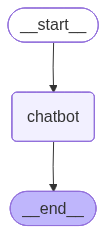

In [11]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [12]:
while True:
  user_input = input("User: ")
  if user_input.lower() in ['quit', 'q']:
    print("Chat Ended")
    break
  events = graph.stream({"messages": ("user", user_input)}, stream_mode="values")
  for event in events:
    event["messages"][-1].pretty_print()

User:  what is weather tomorrow in bangalore


================================ Human Message =================================

what is weather tomorrow in bangalore
================================== Ai Message ==================================

I'm a large language model, I don't have real-time access to current weather conditions or forecasts. But I can suggest some ways for you to find out the weather in Bangalore for tomorrow:

1. **Check online weather websites**: You can visit websites like AccuWeather, Weather.com, or the Indian Meteorological Department (IMD) website to get the latest weather forecast for Bangalore.
2. **Use a weather app**: Download a weather app like Dark Sky, Weather Underground, or Mausam (by IMD) to get the latest weather forecast for Bangalore.
3. **Check social media**: Follow local news channels or weather handles on social media platforms like Twitter or Facebook to get updates on the weather in Bangalore.

As of my knowledge cutoff, I don't have real-time information on the weather in Bangalore

User:  q


Chat Ended
